Try fine-tuning a pretrained ViT model on the Food 101 dataset (torchvision.datasets.Food101). What accuracy can you reach? How about using a CLIP model, zero-shot?

In [1]:
import torch
import torch.nn as nn
import torchvision.datasets
from transformers import ViTForImageClassification, AutoImageProcessor, TrainingArguments, Trainer, pipeline
from datasets import load_dataset

/home/damian/New Folder/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
food_data_train = torchvision.datasets.Food101(root='./food_data', split='train', download=True)
food_data_test  = torchvision.datasets.Food101(root='./food_data', split='test', download=True)

In [46]:
food_data_train[0]

(<PIL.Image.Image image mode=RGB size=512x512>, 23)

In [ ]:
vit_dir = 'google/vit-base-patch16-224-in21k'
vit_model = ViTForImageClassification.from_pretrained(vit_dir, num_labels=len(food_data_train.classes))
vit_processor = AutoImageProcessor.from_pretrained(vit_dir, use_fast=True)

Loading weights: 100%|██████████| 6/6 [00:00<00:00, 18450.02it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
encoder.layer.{0...11}.attention.attention.value.weight | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.weight              | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.weight | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.bias            | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.bias             | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.bias     | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.bias      | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.weight           | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.weight        | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.bias         

In [50]:
def vit_collate_fn(batch):
    images = [example[0] for example in batch]
    labels = [example[1] for example in batch]
    inputs = vit_processor(images, return_tensors='pt', do_convert_rgb=True)
    inputs['labels'] = torch.tensor(labels)
    return inputs

def compute_accuracy(logits_labels):
    logits, labels = logits_labels
    preds = torch.tensor(logits).argmax(dim=1)
    labels = torch.tensor(labels)
    accuracy = (preds == labels).float().mean()
    return {'accuracy' : accuracy.item()}

args = TrainingArguments('./food_data/vit_model', per_device_train_batch_size=16, remove_unused_columns=False,
                         num_train_epochs=1, eval_strategy='epoch', report_to='none')
trainer = Trainer(model=vit_model, args=args, data_collator=vit_collate_fn, train_dataset=food_data_train,
                  eval_dataset=food_data_test, compute_metrics=compute_accuracy)

In [51]:
train_output = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,3.866804,3.774438,0.160198


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.78it/s]


## CLIP

In [ ]:
clip_dir = 'openai/clip-vit-base-patch32'
clip_pipeline = pipeline(task='zero-shot-image-classification', model_id=clip_dir, device_map='auto', dtype='auto')

[transformers] No model was supplied, defaulted to openai/clip-vit-base-patch32 and revision 3d74acf.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 5817.83it/s]


In [55]:
accuracy_list = []
for x in range(25):
    images = []
    for index in range(x*1010, x*1010+1010):
        images.append(food_data_test[index][0])
    results = clip_pipeline(image=images, candidate_labels=food_data_train.classes, hypothesis_template='This is a photo of a {}.')

    y = [food_data_test.classes[food_data_test[i][1]] for i in range(x*1010, x*1010+1010)]

    y_pred = [results[i][0]['label'] for i in range(1010)]

    accuracy_list.append(torch.tensor([y[i] == y_pred[i] for i in range(len(y))], dtype=torch.float16).mean().item())
    

/home/damian/New Folder/.venv/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [56]:
accuracy = torch.tensor(accuracy_list, dtype=torch.float16).mean().item()
print(accuracy)
accuracy_list

0.81201171875


[0.81884765625,
 0.794921875,
 0.81396484375,
 0.8515625,
 0.7685546875,
 0.7021484375,
 0.87109375,
 0.82470703125,
 0.7919921875,
 0.81787109375,
 0.76953125,
 0.75927734375,
 0.8466796875,
 0.73583984375,
 0.83251953125,
 0.81103515625,
 0.8642578125,
 0.81005859375,
 0.76513671875,
 0.857421875,
 0.802734375,
 0.89306640625,
 0.88818359375,
 0.73779296875,
 0.8720703125]

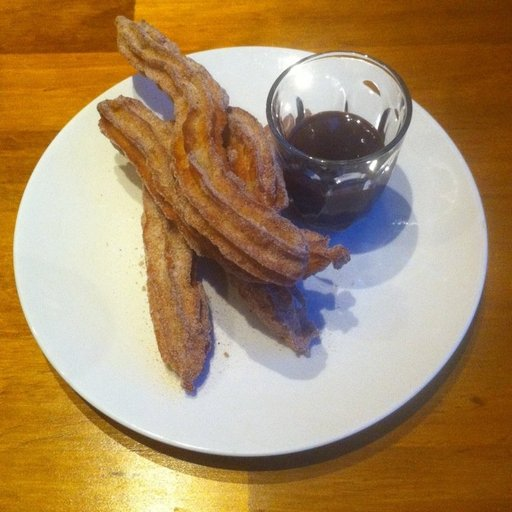

In [51]:
food_data_test[1][0]